<a href="https://colab.research.google.com/github/IuliaBunescu/airline-satisfaction-classification/blob/main/notebooks/811_XGboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn==1.7.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 42.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


### 1. Import Libraries & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff

import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix

import joblib
import warnings
warnings.filterwarnings("ignore")


!pip install shap -q
import shap

print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. Load and Inspect Data

In [ ]:
print("Loading train and test data...")
train_raw = pd.read_csv('/content/train (1).csv', index_col=0)
test_raw = pd.read_csv('/content/test.csv', index_col=0)

print(f"Raw train data shape: {train_raw.shape}")
print(f"Raw test data shape: {test_raw.shape}")
display(train_raw.head(3))

Loading train and test data...
Raw train data shape: (103904, 24)
Raw test data shape: (25976, 24)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied


### 3. Target Definition

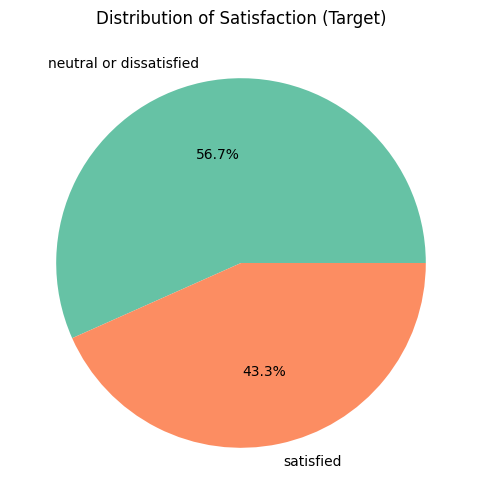

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(train_raw['satisfaction'].value_counts(),
        labels=train_raw['satisfaction'].value_counts().index,
        autopct='%1.1f%%', colors=sns.color_palette("Set2"))
plt.title('Distribution of Satisfaction (Target)')
plt.show()

### 4. Data Preprocessing & Baseline Model Evaluation
Here, we manually preprocess the data (splitting first to prevent data leakage during imputation) and evaluate a baseline XGBoost model on all features.

In [ ]:
# 1. Drop useless columns
cols_to_drop = ['Unnamed: 0', 'id']
train_clean = train_raw.drop(columns=[c for c in cols_to_drop if c in train_raw.columns])
test_clean = test_raw.drop(columns=[c for c in cols_to_drop if c in test_raw.columns])

# 2. Separate Target Variable and Features
y_train = train_clean['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
X_train = train_clean.drop(columns=['satisfaction'])

y_test = test_clean['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
X_test = test_clean.drop(columns=['satisfaction'])

# 3. Handle Missing Values (Arrival Delay) using TRAIN set median
median_delay = X_train['Arrival Delay in Minutes'].median()
X_train['Arrival Delay in Minutes'].fillna(median_delay, inplace=True)
X_test['Arrival Delay in Minutes'].fillna(median_delay, inplace=True)

# 4. Safe Encoding for Baseline & SHAP
# Tree models handle ordinal encoding well. We use OrdinalEncoder for safe mapping of unseen categories.
categorical_cols = X_train.select_dtypes(include=['object']).columns

X_train_base = X_train.copy()
X_test_base = X_test.copy()

from sklearn.preprocessing import OrdinalEncoder
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_base[categorical_cols] = ord_enc.fit_transform(X_train_base[categorical_cols])
X_test_base[categorical_cols] = ord_enc.transform(X_test_base[categorical_cols])

# 5. Train Baseline Model
print("Training Baseline XGBoost Model on ALL features...")
base_xgb = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
base_xgb.fit(X_train_base, y_train)

# 6. Evaluate Baseline on explicitly provided Test Set
base_preds = base_xgb.predict(X_test_base)
print("\n--- Baseline Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, base_preds):.4f}")
print(f"F1-Macro: {f1_score(y_test, base_preds, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, base_preds))

Training Baseline XGBoost Model on ALL features...

--- Baseline Model Performance ---
Accuracy: 0.9633
F1-Macro: 0.9626

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.95      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



#### 4.1 SHAP Value Analysis for Feature Selection

Calculating SHAP values on Training Data to prevent leakage...


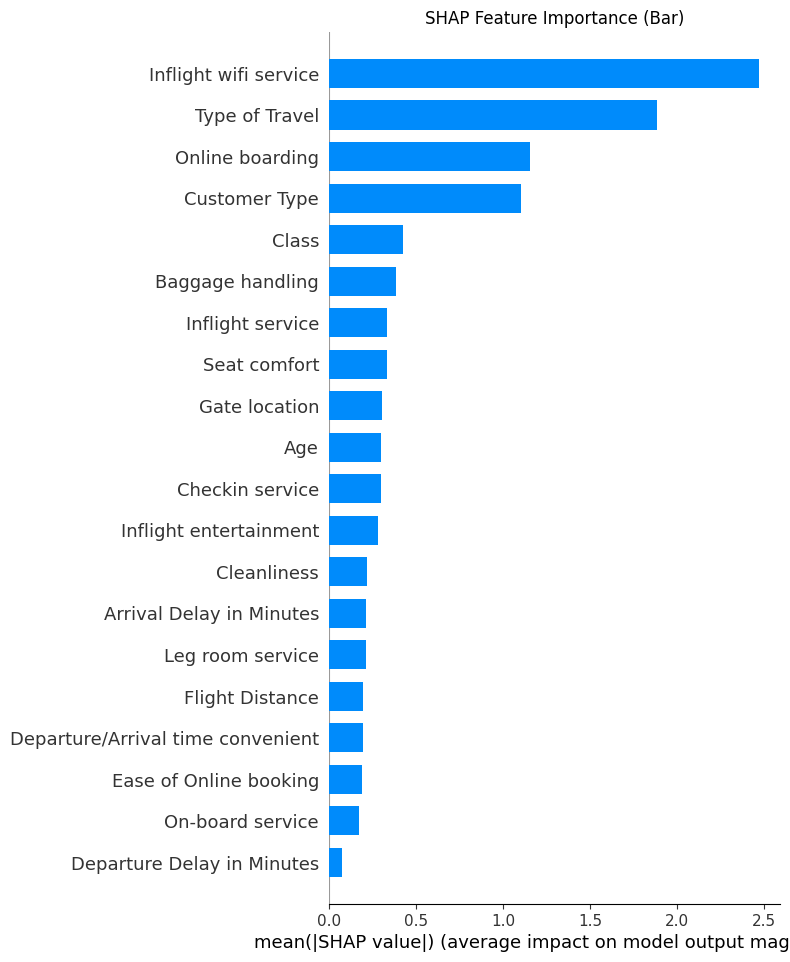

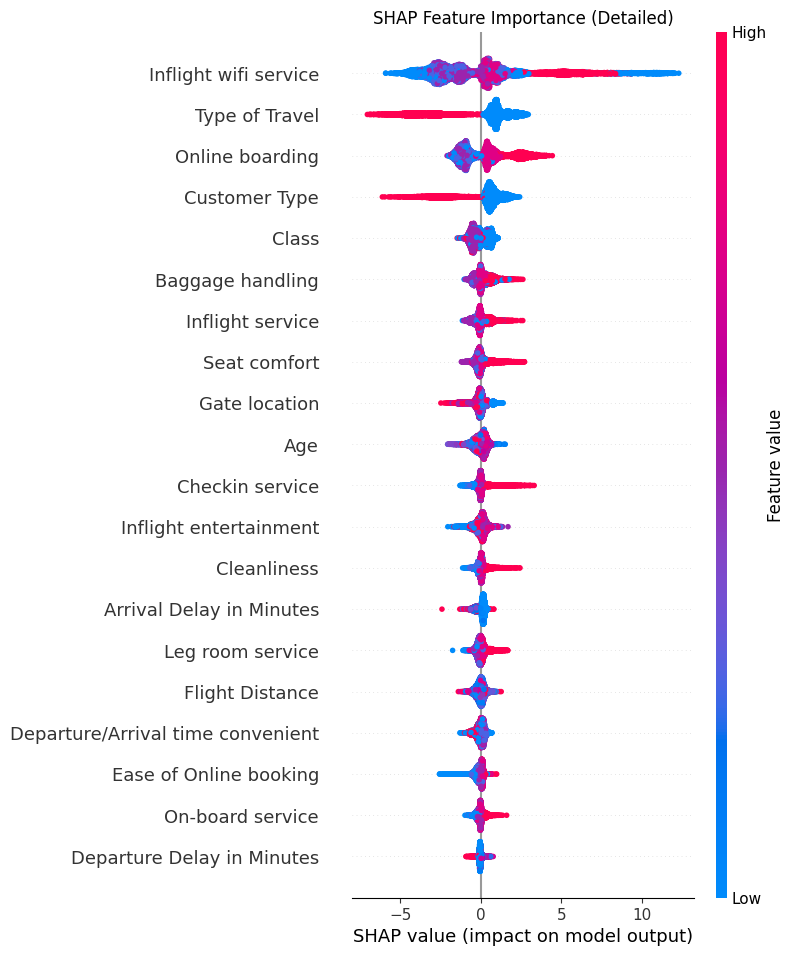

In [ ]:
print("Calculating SHAP values on Training Data to prevent leakage...")
# Calculate SHAP values strictly on the training set.
# We use a sample of 10,000 to keep the computation fast.
X_train_sample = X_train_base.sample(n=10000, random_state=42)

explainer = shap.TreeExplainer(base_xgb)
shap_values = explainer.shap_values(X_train_sample)

# Plot SHAP summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar)")
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_sample, show=False)
plt.title("SHAP Feature Importance (Detailed)")
plt.show()

In [ ]:
### 5. Advanced Feature Selection
#Based on SHAP and XGBoost built-in importance, we select the top features to build a robust and less noisy model, aligning with the SVM pipeline's minimalist approach.

Evaluating optimal number of features based on SHAP ranking...


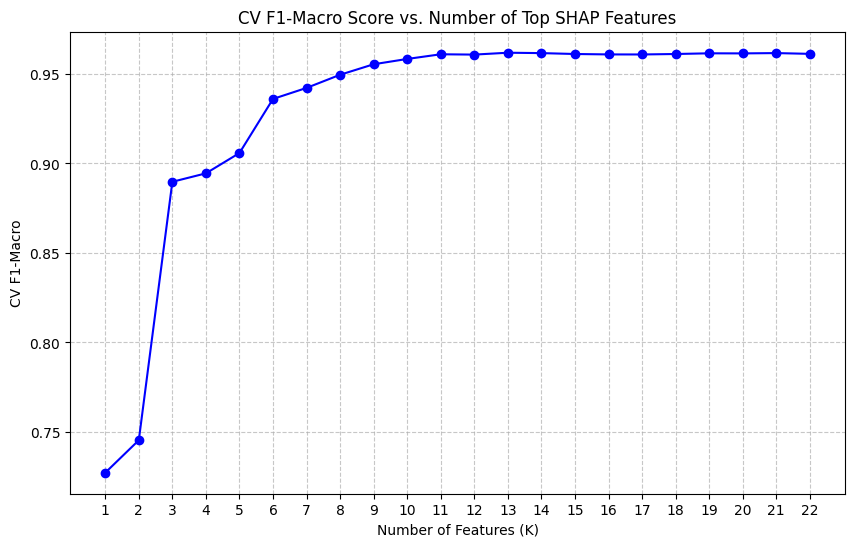

Optimal number of features: 13
Maximum CV F1-Macro: 0.9619

Top 13 Selected Features:
- Inflight wifi service
- Type of Travel
- Online boarding
- Customer Type
- Class
- Baggage handling
- Inflight service
- Seat comfort
- Gate location
- Age
- Checkin service
- Inflight entertainment
- Cleanliness


In [ ]:
from sklearn.model_selection import cross_val_score

# 1. Extract features ordered by SHAP importance
shap_sum = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame([X_train_sample.columns.tolist(), shap_sum.tolist()]).T
importance_df.columns = ['column_name', 'shap_importance']
importance_df = importance_df.sort_values('shap_importance', ascending=False)
ranked_features = importance_df['column_name'].tolist()

# 2. Evaluate optimal number of features (N)
cv_scores = []
k_values = range(1, len(ranked_features) + 1)

print("Evaluating optimal number of features based on SHAP ranking...")
for k in k_values:
    selected_k = ranked_features[:k]
    X_subset = X_train_base[selected_k]

    # Use a fast baseline XGB for evaluation
    temp_xgb = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')

    # Cross-validation
    scores = cross_val_score(temp_xgb, X_subset, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
    cv_scores.append(scores.mean())

# 3. Plot the performance curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b')
plt.title('CV F1-Macro Score vs. Number of Top SHAP Features')
plt.xlabel('Number of Features (K)')
plt.ylabel('CV F1-Macro')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Find the optimal K (max F1 score)
optimal_k = k_values[np.argmax(cv_scores)]
max_f1 = np.max(cv_scores)

print(f"Optimal number of features: {optimal_k}")
print(f"Maximum CV F1-Macro: {max_f1:.4f}")

# 5. Set TOP_N to optimal_k and select features
TOP_N = optimal_k
selected_features = ranked_features[:TOP_N]

print(f"\nTop {TOP_N} Selected Features:")
for f in selected_features:
    print(f"- {f}")

In [ ]:
### 6. Scikit-Learn Pipeline & Hyperparameter Tuning
#ow we create a reproducible pipeline. We will use `OneHotEncoder` for categoricals (standard for mixed pipelines) and tune the XGBoost model using `GridSearchCV` focusing on `f1_macro`.

In [ ]:
# Prepare final data with selected features using the ORIGINAL raw features (before manual imputation)
X_train_pipe = X_train[selected_features]
X_test_pipe = X_test[selected_features]
y_train_pipe = y_train
y_test_pipe = y_test

# Re-evaluate feature types for the pipeline
final_cat_features = [f for f in selected_features if f in categorical_cols]
final_num_features = [f for f in selected_features if f not in categorical_cols]

# Define Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                # Use OneHotEncoder for the final pipeline to be robust
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            final_cat_features
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            final_num_features
        )
    ]
)

# Define the full Pipeline
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("xgb", xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])


from sklearn import set_config
set_config(display="diagram")
display(xgb_pipeline)


,steps,"[('prep', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 6.1 RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define a broader parameter distribution for RandomizedSearchCV
param_dist = {
    'xgb__n_estimators': [100, 200, 300, 400],
    'xgb__max_depth': [3, 5, 7, 9],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__min_child_weight': [1, 3, 5]
}

# Stratified K-Fold for robust evaluation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20, # Number of random parameter combinations to try
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Starting Randomized Search...")
random_search.fit(X_train_pipe, y_train_pipe)

print("\nBest parameters:", random_search.best_params_)
print("Best CV f1_macro:", random_search.best_score_)

Starting Randomized Search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'xgb__subsample': 0.8, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 3, 'xgb__max_depth': 9, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.8}
Best CV f1_macro: 0.9625554692117154


#### 6.2 RandomizedSearchCV Results Visualization
Visualizing the performance of different hyperparameter combinations explored during the random search.

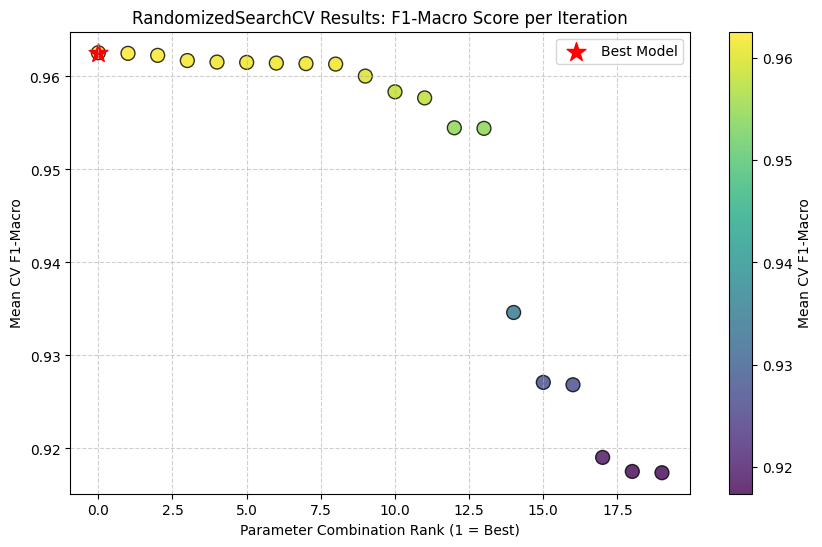

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract CV results into a DataFrame
cv_results = pd.DataFrame(random_search.cv_results_)

# 2. Sort by rank_test_score for better visualization
cv_results = cv_results.sort_values('rank_test_score')

# 3. Create a scatter plot of Mean Test Score (F1-Macro) vs. Iteration
plt.figure(figsize=(10, 6))
plt.scatter(range(len(cv_results)), cv_results['mean_test_score'], c=cv_results['mean_test_score'], cmap='viridis', s=100, alpha=0.8, edgecolor='k')
plt.colorbar(label='Mean CV F1-Macro')
plt.title('RandomizedSearchCV Results: F1-Macro Score per Iteration')
plt.xlabel('Parameter Combination Rank (1 = Best)')
plt.ylabel('Mean CV F1-Macro')
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight the best score
plt.scatter(0, cv_results.iloc[0]['mean_test_score'], color='red', s=200, marker='*', label='Best Model')
plt.legend()
plt.show()

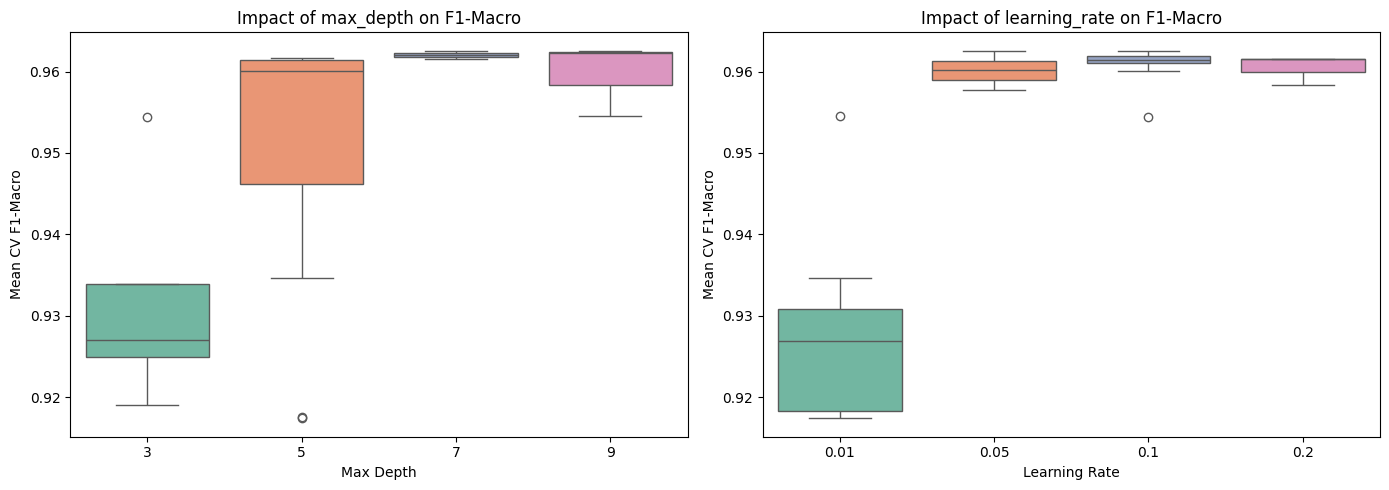

In [ ]:
# 4. Plotting parameter impacts using boxplots (optional but useful)
# Let's see how 'max_depth' and 'learning_rate' affected the score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot for max_depth
sns.boxplot(x='param_xgb__max_depth', y='mean_test_score', data=cv_results, ax=axes[0], palette='Set2')
axes[0].set_title('Impact of max_depth on F1-Macro')
axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('Mean CV F1-Macro')

# Plot for learning_rate
sns.boxplot(x='param_xgb__learning_rate', y='mean_test_score', data=cv_results, ax=axes[1], palette='Set2')
axes[1].set_title('Impact of learning_rate on F1-Macro')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Mean CV F1-Macro')

plt.tight_layout()
plt.show()

### 7. Evaluation & Export Pipeline for Ensemble

--- Tuned Pipeline Performance ---
Test Accuracy: 0.9643902063443178
Test F1 Macro: 0.9637213741076655

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.97      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



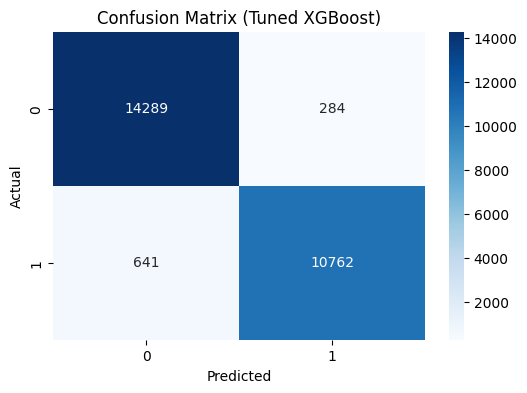

Pipeline successfully saved as 'xgb_pipeline.pkl' for ensemble.


In [ ]:
best_model = random_search.best_estimator_

# Evaluate on Test Set
y_pred = best_model.predict(X_test_pipe)

print("--- Tuned Pipeline Performance ---")
print("Test Accuracy:", accuracy_score(y_test_pipe, y_pred))
print("Test F1 Macro:", f1_score(y_test_pipe, y_pred, average="macro"))
print("\nClassification Report:\n")
print(classification_report(y_test_pipe, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_pipe, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Tuned XGBoost)")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Save the Pipeline for Ensemble
joblib.dump(best_model, "xgb_pipeline.pkl")
print("Pipeline successfully saved as 'xgb_pipeline.pkl' for ensemble.")

In [ ]:
import joblib


loaded_pipeline = joblib.load("xgb_pipeline.pkl")




from sklearn import set_config
set_config(display="diagram")
display(loaded_pipeline)

,steps,"[('prep', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:

test_data = pd.read_csv('test.csv')
x_test = test_data.drop(columns=['Unnamed: 0', 'id'])
y_test = test_data['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})


loaded_preds = loaded_pipeline.predict(x_test)


print("--- Loaded Pipeline Performance ---")
print(f"Accuracy: {accuracy_score(y_test, loaded_preds):.4f}")
print(f"F1 Macro: {f1_score(y_test, loaded_preds, average='macro'):.4f}")



print((y_pred == loaded_preds).all())

--- Loaded Pipeline Performance ---
Accuracy: 0.9644
F1 Macro: 0.9637
True


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, f1_score

print("Training Bagging Ensemble with the best pipeline...")

preprocessor = loaded_pipeline.named_steps['prep']
xgb_model = loaded_pipeline.named_steps['xgb']

X_train_transformed = preprocessor.transform(X_train_pipe)
X_test_transformed = preprocessor.transform(X_test_pipe)

bagging_model = BaggingClassifier(
    estimator=xgb_model,
    n_estimators=5,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(X_train_transformed, y_train_pipe)

bagging_preds = bagging_model.predict(X_test_transformed)

print("\n--- Bagging Ensemble Performance ---")
print(f"Accuracy: {accuracy_score(y_test_pipe, bagging_preds):.4f}")
print(f"F1 Macro: {f1_score(y_test_pipe, bagging_preds, average='macro'):.4f}")


Training Bagging Ensemble with the best pipeline...

--- Bagging Ensemble Performance ---
Accuracy: 0.9641
F1 Macro: 0.9634


In [ ]:
from sklearn.model_selection import GridSearchCV

print("Tuning Bagging Ensemble parameters...")

bagging_param_grid = {
    'n_estimators': [3, 5, 10, 20],
    'max_samples': [0.7, 0.8, 0.9, 1.0],
    'max_features': [0.7, 0.8, 0.9, 1.0]
}

base_bagging = BaggingClassifier(
    estimator=xgb_model,
    random_state=42,
    n_jobs=-1
)

bagging_grid = GridSearchCV(
    base_bagging,
    param_grid=bagging_param_grid,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1
)

bagging_grid.fit(X_train_transformed, y_train_pipe)

print("\nBest Bagging Parameters:", bagging_grid.best_params_)
print(f"Best CV F1-Macro: {bagging_grid.best_score_:.4f}")

best_bagging_model = bagging_grid.best_estimator_
tuned_bagging_preds = best_bagging_model.predict(X_test_transformed)

print("\n--- Tuned Bagging Ensemble Performance (Test Set) ---")
print(f"Accuracy: {accuracy_score(y_test_pipe, tuned_bagging_preds):.4f}")
print(f"F1 Macro: {f1_score(y_test_pipe, tuned_bagging_preds, average='macro'):.4f}")

Tuning Bagging Ensemble parameters...
Fitting 3 folds for each of 64 candidates, totalling 192 fits

Best Bagging Parameters: {'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 20}
Best CV F1-Macro: 0.9622

--- Tuned Bagging Ensemble Performance (Test Set) ---
Accuracy: 0.9642
F1 Macro: 0.9636


### 8. Ensemble Visualization & Advanced Bagging
We explore performance comparison visualizations across models suitable for presentation materials, as well as the Random Subspaces bagging technique which samples only a subset of features.

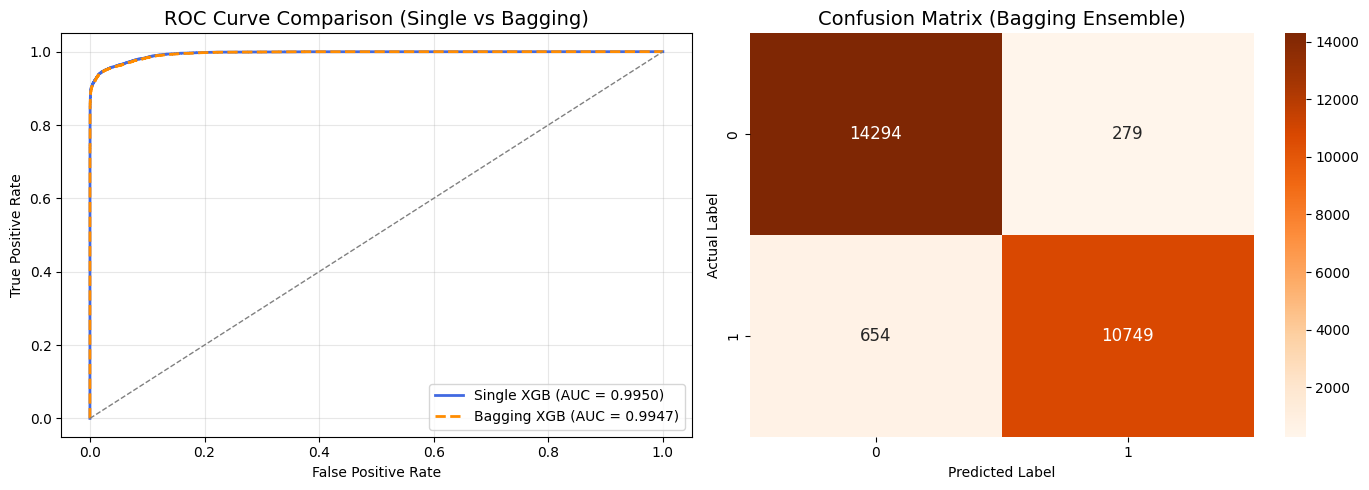

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract prediction probabilities (for ROC curve)
single_probs = loaded_pipeline.predict_proba(X_test_pipe)[:, 1]
bagging_probs = bagging_model.predict_proba(X_test_transformed)[:, 1]

# 2. Calculate ROC curve data
fpr_single, tpr_single, _ = roc_curve(y_test_pipe, single_probs)
roc_auc_single = auc(fpr_single, tpr_single)

fpr_bag, tpr_bag, _ = roc_curve(y_test_pipe, bagging_probs)
roc_auc_bag = auc(fpr_bag, tpr_bag)

# 3. Visualization (Figure setup)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: ROC Curve Comparison ---
ax[0].plot(fpr_single, tpr_single, color='royalblue', lw=2, label=f'Single XGB (AUC = {roc_auc_single:.4f})')
ax[0].plot(fpr_bag, tpr_bag, color='darkorange', lw=2, linestyle='--', label=f'Bagging XGB (AUC = {roc_auc_bag:.4f})')
ax[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax[0].set_title('ROC Curve Comparison (Single vs Bagging)', fontsize=14)
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# --- Plot 2: Confusion Matrix (Bagging) ---
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_pipe, bagging_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax[1], annot_kws={"size": 12})
ax[1].set_title('Confusion Matrix (Bagging Ensemble)', fontsize=14)
ax[1].set_ylabel('Actual Label')
ax[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


#### 8.1 Advanced Bagging: Random Subspaces & OOB Evaluation
We maximize the diversity of individual models by sampling not only the data but also the **features (`max_features < 1.0`)**. Additionally, we check the **OOB Score**, which allows the model to self-evaluate using the samples not included in the training set (Out-of-Bag).

In [ ]:
print("Training Advanced Bagging Ensemble (Random Subspaces & OOB Score)...")

# Apply Random Subspaces technique (train each model using randomly selected 80% of features)
advanced_bagging = BaggingClassifier(
    estimator=xgb_model,
    n_estimators=10,        # Increase the number of trees for stability of OOB evaluation
    max_features=0.8,       # Sample only 80% of features (Random Subspaces)
    bootstrap=True,         # Bootstrap sampling for data (Bagging)
    oob_score=True,         # Enable Out-of-Bag validation
    random_state=42,
    n_jobs=-1
)

# Train the model
advanced_bagging.fit(X_train_transformed, y_train_pipe)

# Evaluate performance
print(f"\n[Validation] OOB Score (Out-of-Bag Accuracy): {advanced_bagging.oob_score_:.4f}")

adv_preds = advanced_bagging.predict(X_test_transformed)
print("\n--- Advanced Bagging Performance (Test Set) ---")
print(f"Test Accuracy: {accuracy_score(y_test_pipe, adv_preds):.4f}")
print(f"Test F1 Macro: {f1_score(y_test_pipe, adv_preds, average='macro'):.4f}")


### 9. Results Summary

| Dataset | Model | Best params | Macro Avg F1-Score | Notes | Time (test-train) |
| :--- | :--- | :--- | :--- | :--- |:--- |
| test | Majority Class (Baseline) |  | 0.36170 | grounding | 0.3s |
| test | kernel SVM (RBF) | C=100, gamma: scale | 0.9284  | best SVM | 1m 39s - 10m |
| test | XGBoost (Tuned) | `n_estimators=200`, `max_depth=9`, `lr=0.05`, `subsample=0.8`, `colsample_bytree=0.8` | 0.9637 | Top 13 SHAP features | N/A |
| test | Stacking | Meta Mode: LR | 0.96261| | 11m |
| test | Bagging (XGBoost) | `n_estimators=5`, Base: Tuned XGBoost | 0.9634 | Bagging Ensemble | N/A |